<a href="https://colab.research.google.com/github/jeeva477/NLP/blob/main/nlp_proj9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
!pip install -q nltk textblob wordcloud kagglehub

import os
import re
import pandas as pd
import nltk
import matplotlib.pyplot as plt
import kagglehub

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
from wordcloud import WordCloud

# --------------------------
# Download NLTK resources
# --------------------------
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [15]:
path = kagglehub.dataset_download('datafiniti/consumer-reviews-of-amazon-products')

print('Dataset downloaded to:', path)

Using Colab cache for faster access to the 'consumer-reviews-of-amazon-products' dataset.
Dataset downloaded to: /kaggle/input/consumer-reviews-of-amazon-products


In [18]:
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
print('CSV Files:', csv_files)

# Load dataset
df = pd.read_csv(os.path.join(path, csv_files[0]))

print('\\nFirst 5 rows:')
print(df.head())

print('\\nColumns:')
print(df.columns)


CSV Files: ['Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv', '1429_1.csv', 'Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv']
\nFirst 5 rows:
                     id             dateAdded           dateUpdated  \
0  AVqVGZNvQMlgsOJE6eUY  2017-03-03T16:56:05Z  2018-10-25T16:36:31Z   
1  AVqVGZNvQMlgsOJE6eUY  2017-03-03T16:56:05Z  2018-10-25T16:36:31Z   
2  AVqVGZNvQMlgsOJE6eUY  2017-03-03T16:56:05Z  2018-10-25T16:36:31Z   
3  AVqVGZNvQMlgsOJE6eUY  2017-03-03T16:56:05Z  2018-10-25T16:36:31Z   
4  AVqVGZNvQMlgsOJE6eUY  2017-03-03T16:56:05Z  2018-10-25T16:36:31Z   

                                                name       asins   brand  \
0  Amazon Kindle E-Reader 6" Wifi (8th Generation...  B00ZV9PXP2  Amazon   
1  Amazon Kindle E-Reader 6" Wifi (8th Generation...  B00ZV9PXP2  Amazon   
2  Amazon Kindle E-Reader 6" Wifi (8th Generation...  B00ZV9PXP2  Amazon   
3  Amazon Kindle E-Reader 6" Wifi (8th Generation...  B00ZV9PXP2  Amazon   
4  Amazon Kindle E-Read

In [20]:
review_col = None

for col in df.columns:
    if 'review' in col.lower():
        review_col = col
        break

if review_col is None:
    raise ValueError('No review column found in the dataset.')

df = df[[review_col]].dropna()

df.rename(columns={review_col: 'Feedback'}, inplace=True)

# Use first 1000 reviews
df = df.head(1000)

print('\\nDataset size:', len(df))


\nDataset size: 1000


In [22]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\\S+|www\\S+', '', text)

    # Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\\s]', ' ', text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words and len(word) > 2
    ]

    return ' '.join(words)

df['Clean_Text'] = df['Feedback'].apply(preprocess_text)

print('\\nPreprocessed Text:')
print(df[['Feedback', 'Clean_Text']].head())



\nPreprocessed Text:
                                            Feedback  \
0  I order 3 of them and one of the item is bad q...   
1  Bulk is always the less expensive way to go fo...   
2  Well they are not Duracell but for the price i...   
3  Seem to work as well as name brand batteries a...   
4  These batteries are very long lasting the pric...   

                                          Clean_Text  
0  order one item bad quality missing backup spri...  
1        bulk always less expensive way product like  
2                          well duracell price happy  
3  seem work well name brand battery much better ...  
4                   battery long lasting price great  


In [23]:
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0.05:
        return 'Positive'
    elif polarity < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment'] = df['Clean_Text'].apply(get_sentiment)

print('\\nSentiment Sample:')
print(df[['Feedback', 'Sentiment']].head())

\nSentiment Sample:
                                            Feedback Sentiment
0  I order 3 of them and one of the item is bad q...  Negative
1  Bulk is always the less expensive way to go fo...  Negative
2  Well they are not Duracell but for the price i...  Positive
3  Seem to work as well as name brand batteries a...  Positive
4  These batteries are very long lasting the pric...  Positive


\nSentiment Counts:
Sentiment
Positive    693
Neutral     199
Negative    108
Name: count, dtype: int64


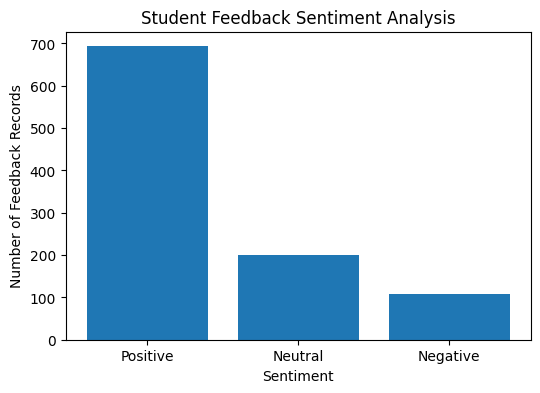

In [24]:
sentiment_counts = df['Sentiment'].value_counts()

print('\\nSentiment Counts:')
print(sentiment_counts)

plt.figure(figsize=(6,4))
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.title('Student Feedback Sentiment Analysis')
plt.xlabel('Sentiment')
plt.ylabel('Number of Feedback Records')
plt.show()


In [27]:
from collections import Counter

negative_feedback = df[df['Sentiment'] == 'Negative']

negative_words = ' '.join(negative_feedback['Clean_Text']).split()

common_concerns = Counter(negative_words).most_common(15)

print('\nMost Common Student Concerns:')

for word, count in common_concerns:
    print(f'{word}: {count}')


Most Common Student Concerns:
battery: 136
amazon: 29
last: 26
long: 24
brand: 22
dead: 20
remote: 19
one: 17
buy: 17
month: 16
use: 16
less: 15
used: 15
work: 14
like: 14


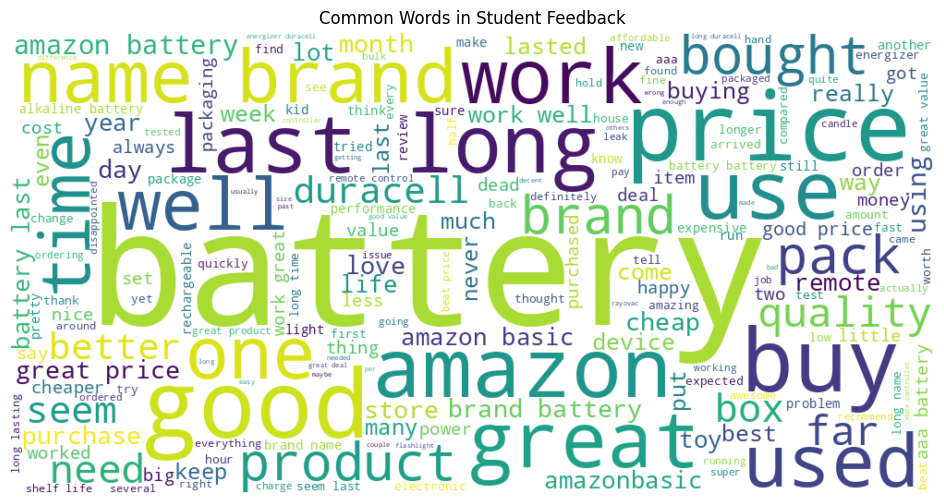

In [28]:
all_text = ' '.join(df['Clean_Text'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(all_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Common Words in Student Feedback')
plt.show()

In [29]:
print('\\nTop 10 Negative Feedback Examples:')

print(
    negative_feedback['Feedback']
    .head(10)
    .to_string(index=False)
)

\nTop 10 Negative Feedback Examples:
I order 3 of them and one of the item is bad qu...
Bulk is always the less expensive way to go for...
Bought these batteries for my Christmas gifts t...
they seemed to not last as long as other name b...
  These last as well as Energizer- half the price.
Arrived earlier than expected. Amazon batteries...
Sorry to say I've been disappointed with these....
I got tired of running back and forth to the lo...
I can only use these on those indoor flameless ...
TERRIBLE! Barely lasted three hours during a di...


In [30]:
total = len(df)
positive = (df['Sentiment'] == 'Positive').sum()
negative = (df['Sentiment'] == 'Negative').sum()
neutral = (df['Sentiment'] == 'Neutral').sum()

print('\\nAcademic Insights')
print('--------------------------------')
print(f'Total Feedback Records : {total}')
print(f'Positive Feedback      : {positive}')
print(f'Negative Feedback      : {negative}')
print(f'Neutral Feedback       : {neutral}')

print('\\nImprovement Suggestions:')

if negative > 0:
    print('- Improve teaching methods for difficult topics.')
    print('- Increase practical and interactive learning sessions.')
    print('- Provide better learning resources and study materials.')
    print('- Reduce repetitive assignments where necessary.')
    print('- Improve classroom and laboratory facilities.')
    print('- Offer additional doubt-clearing and mentoring sessions.')
else:
    print('- Students are generally satisfied with the learning experience.')

\nAcademic Insights
--------------------------------
Total Feedback Records : 1000
Positive Feedback      : 693
Negative Feedback      : 108
Neutral Feedback       : 199
\nImprovement Suggestions:
- Improve teaching methods for difficult topics.
- Increase practical and interactive learning sessions.
- Provide better learning resources and study materials.
- Reduce repetitive assignments where necessary.
- Improve classroom and laboratory facilities.
- Offer additional doubt-clearing and mentoring sessions.
